# Pauli Propagation

In [1]:
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp, commutator

import math
from functools import partial
import numpy as np
from numpy.linalg import matrix_power
from matplotlib import pyplot as plt

from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf, expH
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from pauli import *

fig_dir, data_dir = './figs', './data'
set_fontsize(linewidth=2.0)

## 2-norm dynamics

In [4]:
# n = 10
n = 8
# t_num = 50
t_num = 200
t = n
hx, hy, Jx = 1, 0.9, 0.8
print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
# qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qimf = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par

r = t_num
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_list), dt, use_jax=False)
U_dt_appro = pf(H_list, dt, 1, 1)
init_state_str = '0'*n
# init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

# z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1) + SparsePauliOp('I'*(n-3)+'XXZ', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1)
z1 = SparsePauliOp('I'*(n-2)+'XX', 1) + SparsePauliOp('I'*(n-1)+'X', 1)
commutator(qimf.ham[0], qimf.ham[3]).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j]))

ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal, i)@init_state) for i in range(r)]

QIMF model with hx=1, hy=0.9, Jx=0.8, n=8
t=8, r=200, dt=0.04


cumulative_norm_steps: [[2.0, 1.0, 0, 0, 0, 0, 0, 0], [1.996325720809256, 0.997530148777353, 0, 0, 0, 0, 0, 0], [1.992496597559201, 0.9948015768691006, 0.0001849492857416466, 0, 0, 0, 0, 0], [1.9884667427106495, 0.9915888368323053, 0.0007191507671755884, 1.0595613965927177e-08, 0, 0, 0, 0], [1.9841573438947655, 0.9876058545316272, 0.001928107655553834, 9.185067857231497e-08, 4.2636676368040433e-13, 0, 0, 0], [1.9795193863066793, 0.9826398317506632, 0.00415918406773034, 4.783824704781796e-07, 6.566063868117418e-12, 0, 0, 0], [1.9745236769244858, 0.9766159685731068, 0.007767079609584137, 1.8192721033953662e-06, 5.591738331951259e-11, 1.7891220325486436e-16, 0, 0], [1.9691610257994154, 0.969662340437285, 0.013082504162070007, 5.574288282341794e-06, 3.298704446665315e-10, 3.606268498279786e-15, 0, 0], [1.9611345950805976, 0.9610161885503532, 0.020364613716998037, 1.4561869245143646e-05, 1.5003889724198275e-09, 3.703928363463196e-14, 0, 0], [1.954003903915291, 0.9524838957084882, 0.02987654

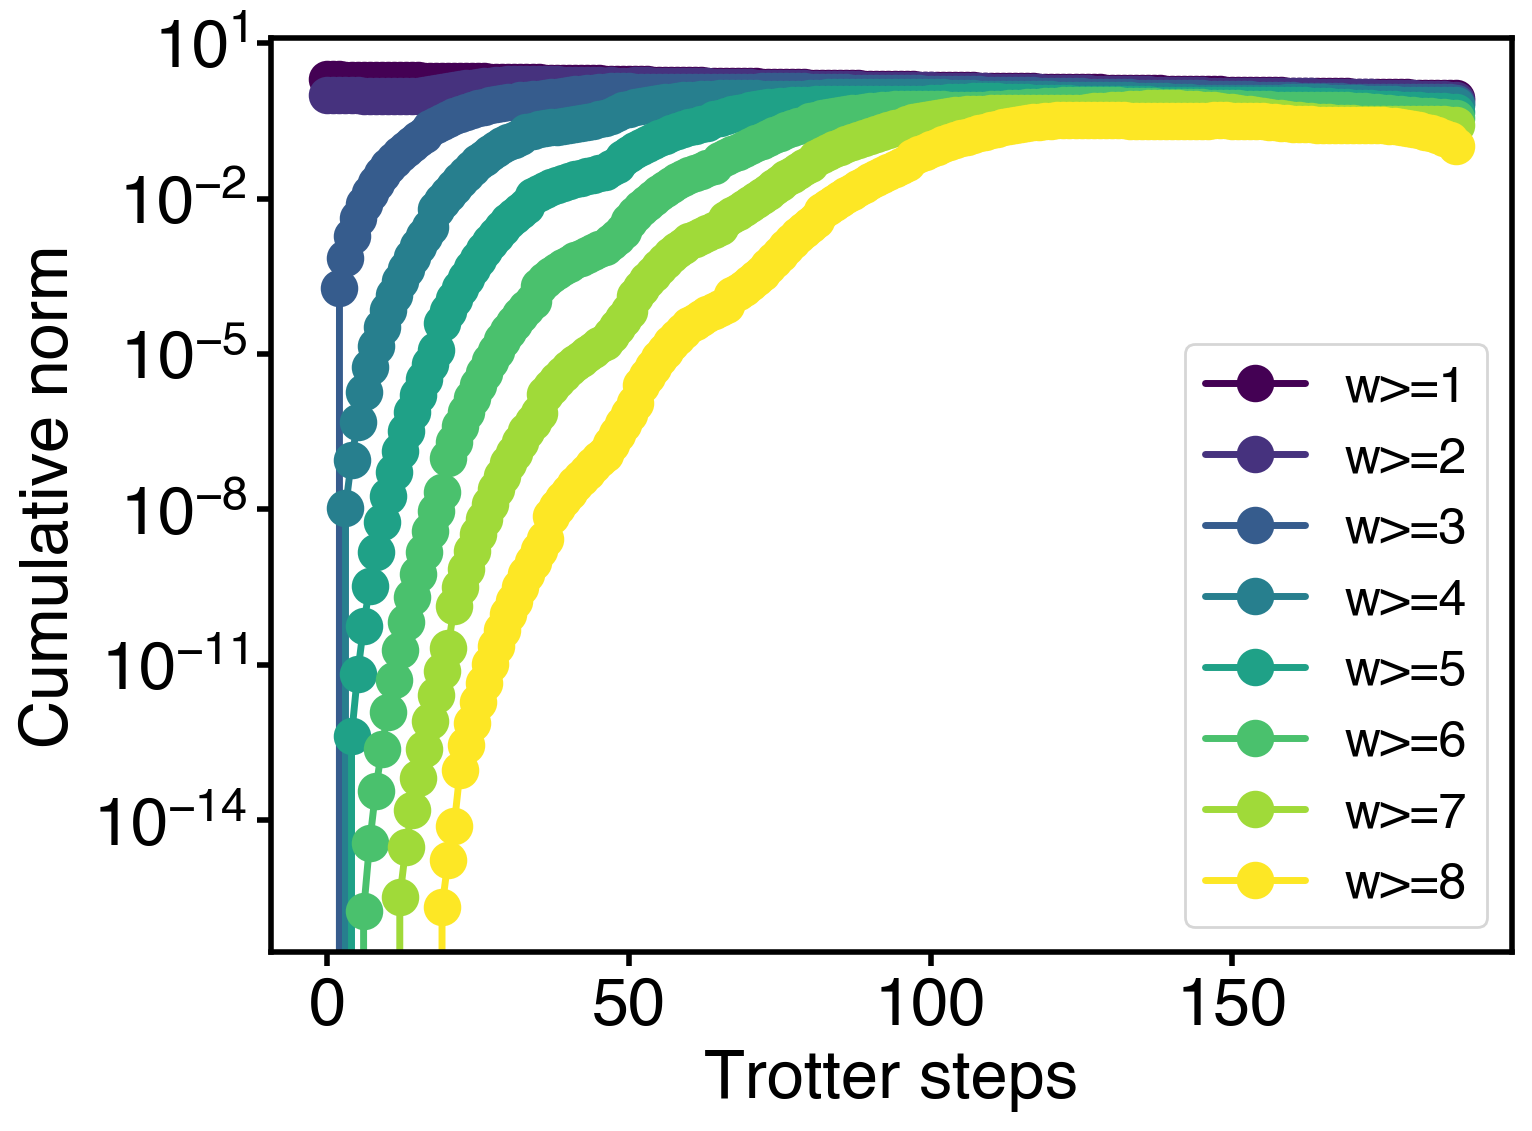

In [5]:
c, s = math.cos(dt*2), math.sin(dt*2)

evo_ob = [z1]
for i in range(r):
    for g in list(qimf.ham):
        # print(g)
        temp = []
        for item in list(evo_ob[-1]):
            # print(item)
            if commutator(g, item).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j])):
                # print(item, g)
                temp.append(item)
            else:
                branch = pauli_rotation_evo(g, dt, item, coeffs=[c,s])
                # branch = c*item + 1j*s*g@item
                temp.append(branch)
        ob_g = sum(temp).simplify()
        # temp_step.append(ob_g)
        evo_ob.append(ob_g)
        # print(f"#Pauli={len(list(ob_g))}, 2-norm={np.linalg.norm(ob_g, ord='fro')/ np.sqrt(2**n)}")
# print('evo_ob:', evo_ob)

data_distribution = []
exp_vals = []
for item in evo_ob[::2*n]:
    weight_norm_dict = pauli_weight_norm(item)
    # print(len(list(item)), weight_norm_dict)
    data_distribution.append(weight_norm_dict)


cumulative_norm_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    # print(item)
    for w in range(1, n+1):
        temp_sum = 0
        for k in range(w, n+1):
            if k in item:
                # print('k', k, item[k])
                temp_sum += item[k]
        # print('sum',temp_sum)
        temp_step.append(temp_sum)
        # print(item, temp_step)
    cumulative_norm_steps.append(temp_step)
print('cumulative_norm_steps:', cumulative_norm_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_norm_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(cumulative_norm_steps[0])):
    ax.plot(range(len(cumulative_norm_steps)), np.array(cumulative_norm_steps)[:,w], label=f'w>={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Cumulative norm')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/cumulative_norm_steps.pdf', bbox_inches='tight')

In [ ]:
print(low_weight_pauli(evo_ob[-1], 3))

# expvals, expvals_1, expvals_3, expvals_6 = [], [], [], []
expvals, expvals_low, expvals_w = [], [], []
for item in evo_ob[::2*n]:
    expvals.append(expect_value(item.to_matrix(), init_state))
    # expvals_1.append(expect_value(low_weight_pauli(item, 1).to_matrix(), init_state))
    temp_w, temp_low = [], []
    for w in range(1, n+1):
        temp_w.append(abs(expect_value(w_weight_pauli(item, w).to_matrix(), init_state)))
        temp_low.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
        # temp.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
    expvals_w.append(temp_w)
    expvals_low.append(temp_low)
expvals_w, expvals_low = np.array(expvals_w), np.array(expvals_low)


SparsePauliOp(['IIIIIIXX', 'IIIIIIZX', 'IIIIIIXZ', 'IIIIIIZZ', 'IIIIIXYX', 'IIIIIZYX', 'IIIIIXYZ', 'IIIIIZYZ', 'IIIIIIYI', 'IIIIIXZI', 'IIIIIZZI', 'IIIIIXXI', 'IIIIIZXI', 'IIIIIIIY', 'IIIIXYZI', 'IIIIZYZI', 'IIIIXYXI', 'IIIIZYXI', 'IIIIIYII', 'IIIIXZII', 'IIIIZZII', 'IIIIXXII', 'IIIIZXII', 'IIIXYZII', 'IIIZYZII', 'IIIXYXII', 'IIIZYXII', 'IIIIYIII', 'IIIXZIII', 'IIIZZIII', 'IIIXXIII', 'IIIZXIII', 'IIXYZIII', 'IIZYZIII', 'IIXYXIII', 'IIZYXIII', 'IIIYIIII', 'IIXZIIII', 'IIZZIIII', 'IIXXIIII', 'IIZXIIII', 'IXYZIIII', 'IZYZIIII', 'IXYXIIII', 'IZYXIIII', 'IIYIIIII', 'IXZIIIII', 'IZZIIIII', 'IXXIIIII', 'IZXIIIII', 'XYZIIIII', 'ZYZIIIII', 'XYXIIIII', 'ZYXIIIII', 'IYIIIIII', 'XZIIIIII', 'ZZIIIIII', 'XXIIIIII', 'ZXIIIIII', 'YIIIIIII', 'IIIIIIIX', 'IIIIIIIZ', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY'],
              coeffs=[ 0.009039+0.j,  0.00599 +0.j,  0.003557+0.j,  0.004895+0.j, -0.014122+0.j,
 -0.004646+0.j,  0.005503+0.j, -0.014651+0.j,  0.006245+0.j, -0.008856+0.j,
 -0.000828+0.j,  0.

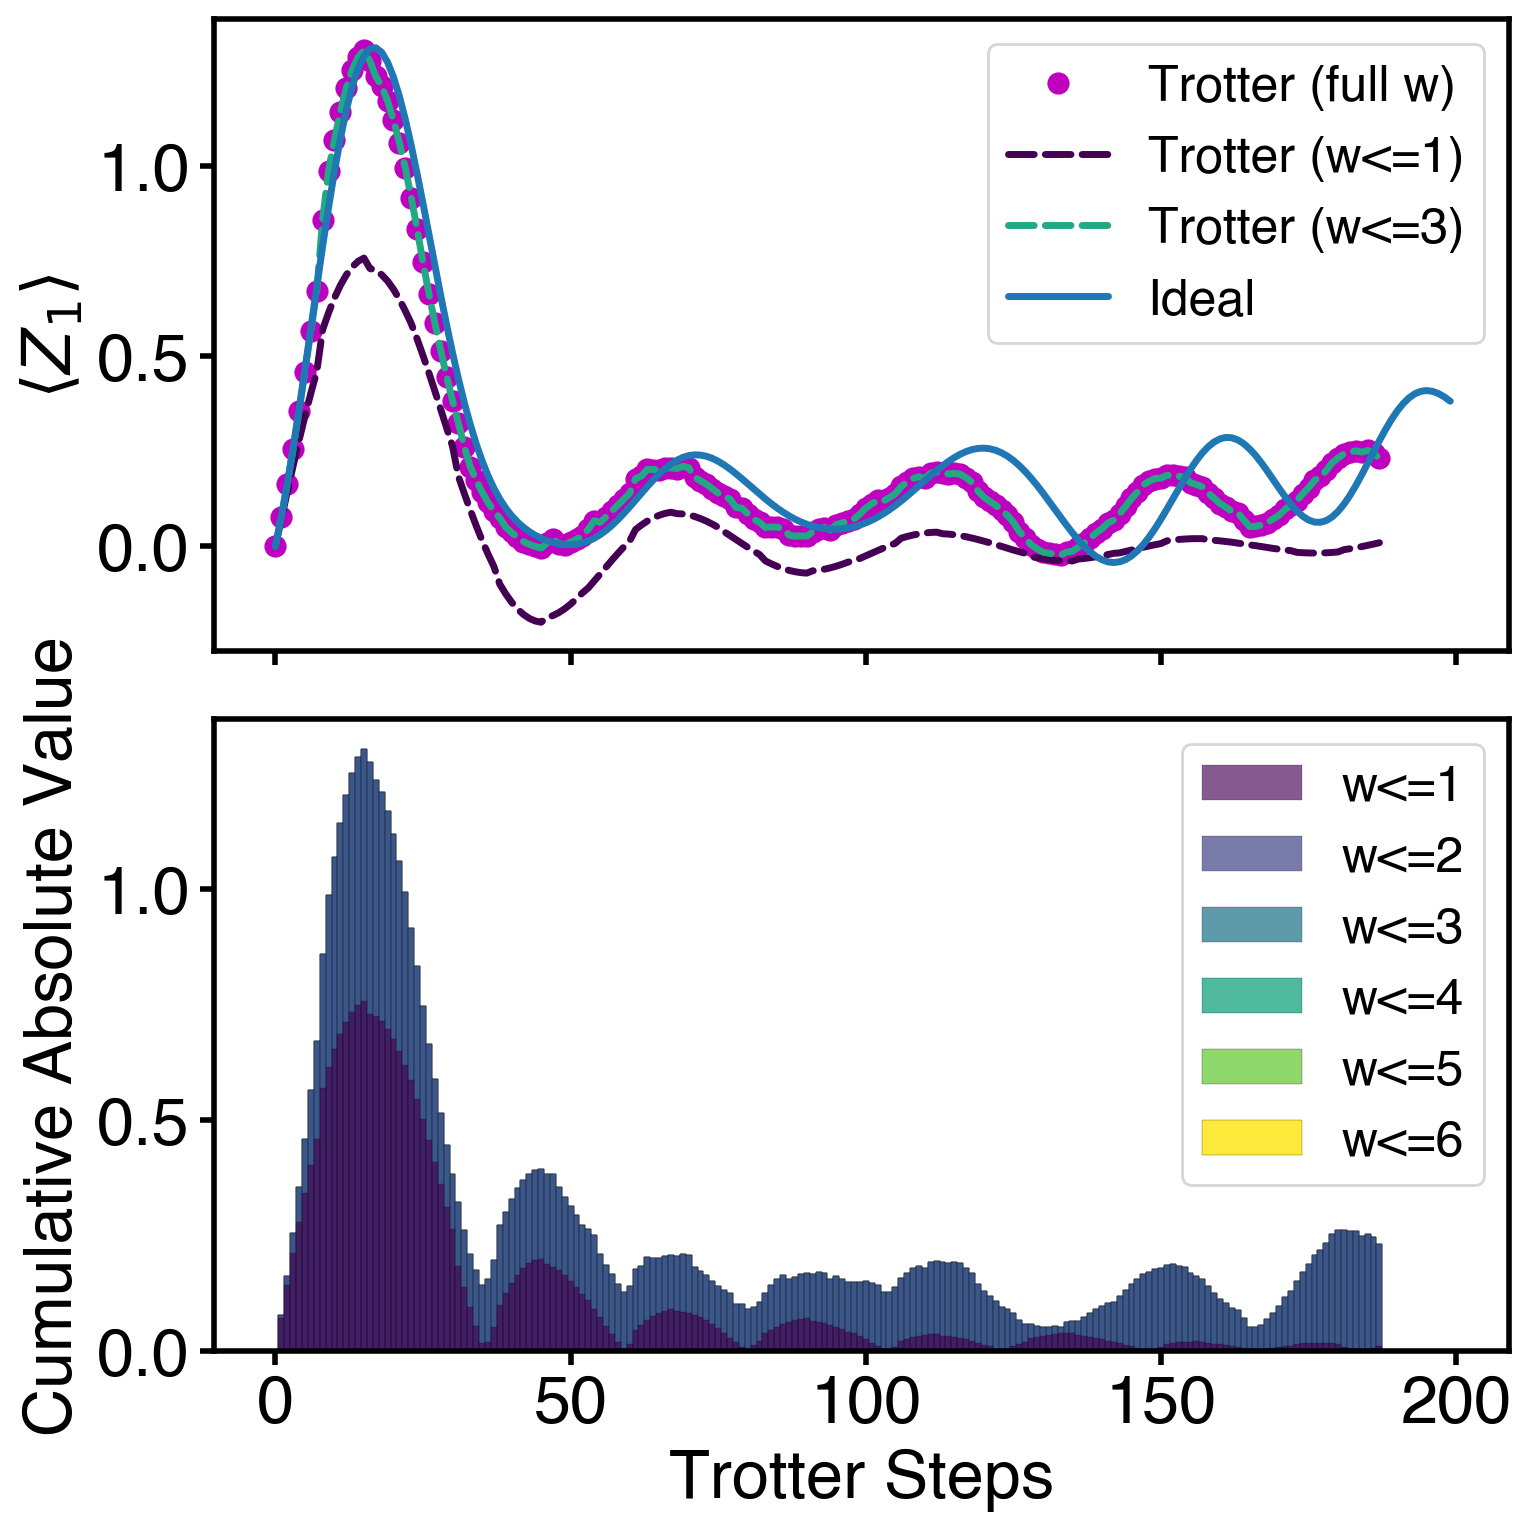

In [69]:
t_list = list(range(len(expvals)))

# Use wider spacing between bars for better visibility
x_pos = np.arange(len(expvals_w)) 
bar_width = 1.0
k = 6
colors = plt.cm.viridis(np.linspace(0.0, 1, k))

fig, [ax, ax2] = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
ax.plot(t_list, expvals, '.', label='Trotter (full w)', c='m')
ax.plot(t_list, expvals_low[:, 0], '--', label='Trotter (w<=1)', color=colors[0])
ax.plot(t_list, expvals_low[:, 1], '--', label='Trotter (w<=3)', color=colors[3])
# ax.plot(t_list, expvals_low[:, 5], '--', label='Trotter (w<=5)', color=colors[5])
ax.plot(range(len(ideal_expvals)), ideal_expvals, '-', label='Ideal')
# ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'$\langle Z_1 \rangle$')
ax.legend()

# Plot with different alpha values for better layering effect
for w in range(k, 0, -1):
    cumulative_values = [sum(expvals_w[i][:w]) for i in range(len(expvals_w))]
    # Vary alpha based on w value
    alpha = 0.6 + (w / n) * 0.4
    bars = ax2.bar(x_pos, cumulative_values, bar_width, color=colors[w-1], alpha=alpha, label=f'w<={w}',
                    edgecolor='black',
                    linewidth=0.1)

ax2.set_xlabel('Trotter Steps')
ax2.set_ylabel('Cumulative Absolute Value')
# ax2.set_title('Cumulative Values with Enhanced Visibility')

handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[::-1], labels[::-1], loc='upper right')

fig.savefig(f'{fig_dir}/expvals_pauli.pdf', bbox_inches='tight')

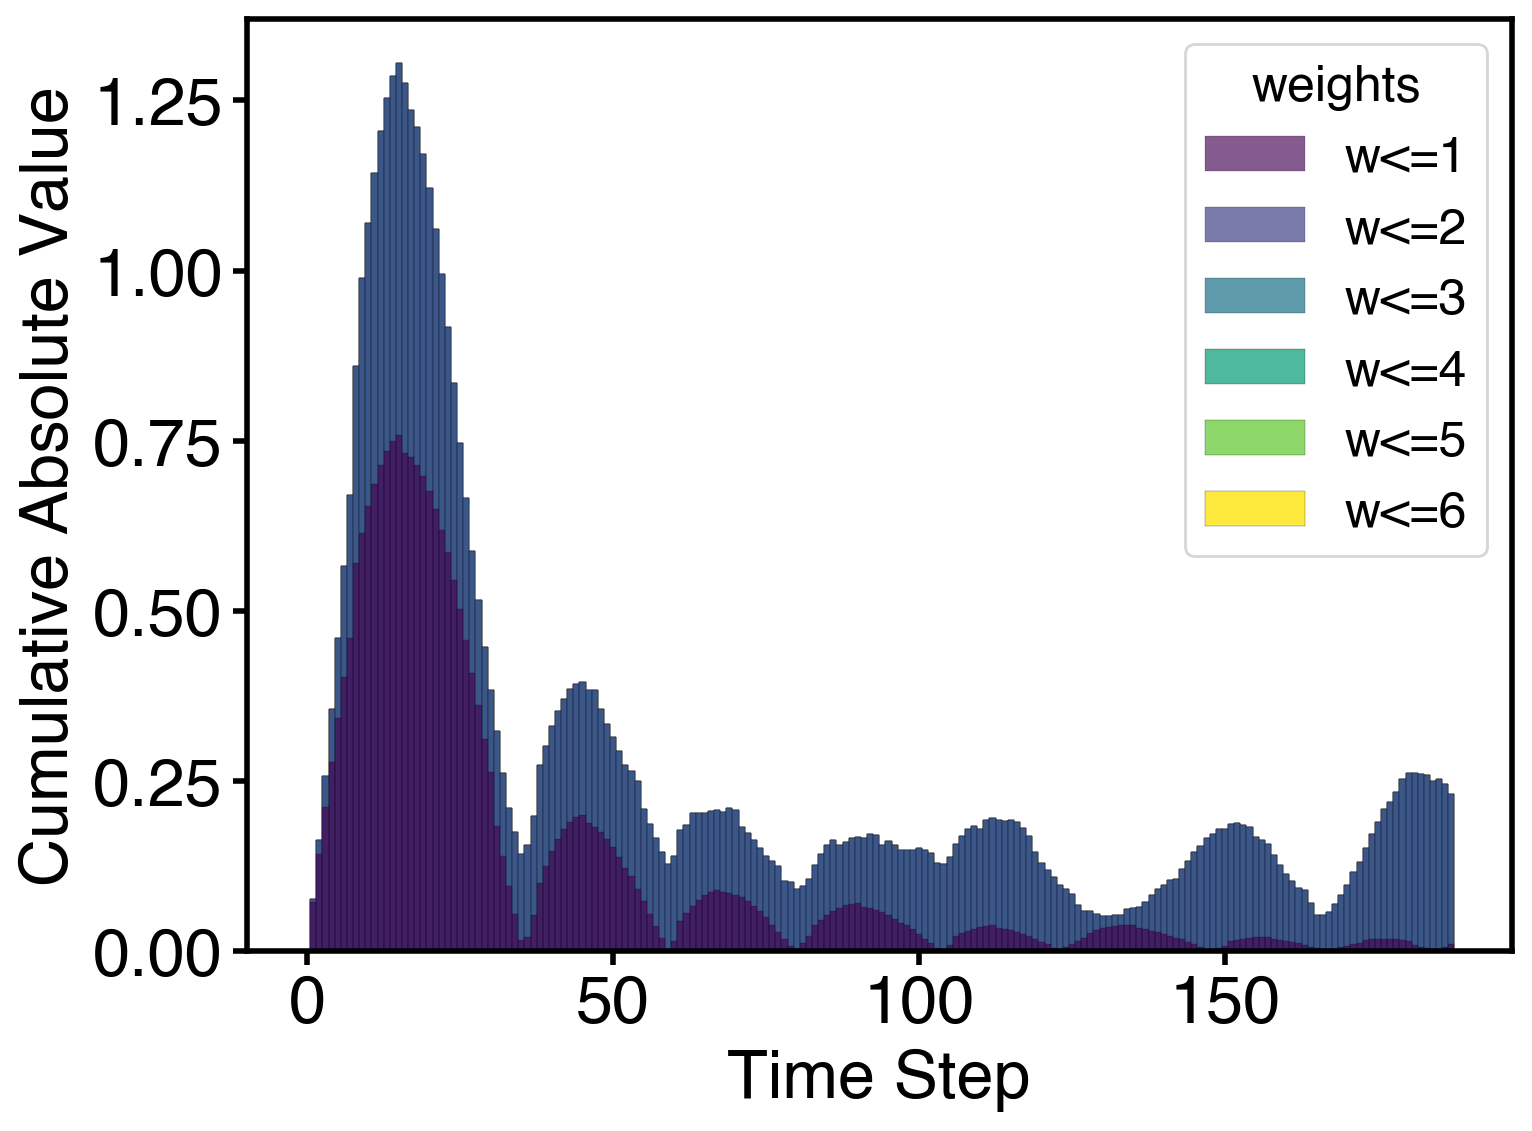

In [ ]:

# Alternative: Create a more customized version with better visibility
fig2, ax2 = plt.subplots()




In [90]:
expvals_w

[[1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0],
 [0.9863615764078778,
  1.9768184930886297,
  1.9768184930886297,
  1.9768184930886297,
  1.9768184930886297,
  1.9768184930886297,
  1.9768184930886297,
  1.9768184930886297],
 [0.9668471241548712,
  1.922738646550535,
  1.922738646550535,
  1.922738646550535,
  1.922738646550535,
  1.922738646550535,
  1.922738646550535,
  1.922738646550535],
 [0.9385171948897746,
  1.8544433426582554,
  1.8544433426582554,
  1.8544433426582554,
  1.8544433426582554,
  1.8544433426582554,
  1.8544433426582554,
  1.8544433426582554],
 [0.901730993309274,
  1.7667009002907332,
  1.7667009002907332,
  1.7667009002907332,
  1.7667009002907332,
  1.7667009002907332,
  1.7667009002907332,
  1.7667009002907332],
 [0.8569431282956137,
  1.6620229078785662,
  1.6620229078785662,
  1.6620229078785662,
  1.6620229078785662,
  1.6620229078785662,
  1.6620229078785662,
  1.6620229078785662],
 [0.8046974501682993,
  1.543338781165256,
  1.543338781165256,
  1.543338781165

norm_weight_steps: [[1.0, 1.0, 0, 0, 0, 0, 0, 0], [0.9780908214259784, 1.0073007071161395, 0.004077221422030807, 0, 0, 0, 0, 0], [0.955433568441743, 0.9879837251328397, 0.035602122100440316, 8.608260111737694e-08, 0, 0, 0, 0], [0.9269191868146107, 0.9823868447519604, 0.0615735585628755, 8.355998872955334e-06, 1.8174777378679867e-12, 0, 0, 0], [0.8941796187433662, 0.9757325646057736, 0.09286609605473486, 3.2649858316165895e-05, 7.781201519838029e-10, 0, 0, 0], [0.8590385011002991, 0.9676618992726211, 0.1280094624089833, 9.714801311501322e-05, 5.4090588236717655e-09, 4.554816268580073e-14, 0, 0], [0.8233362995625625, 0.958012903513985, 0.16531210977702945, 0.00024019513431400977, 2.664939130666911e-08, 5.22480812942681e-13, 0, 0], [0.7887678801219783, 0.9469056096588041, 0.20293200487122154, 0.0005185527059006904, 1.0320416565796367e-07, 3.861799203316881e-12, 0, 0], [0.7558722042537033, 0.9339450829065262, 0.23868408538097668, 0.0010069293092491887, 3.334798720962499e-07, 2.151498662569

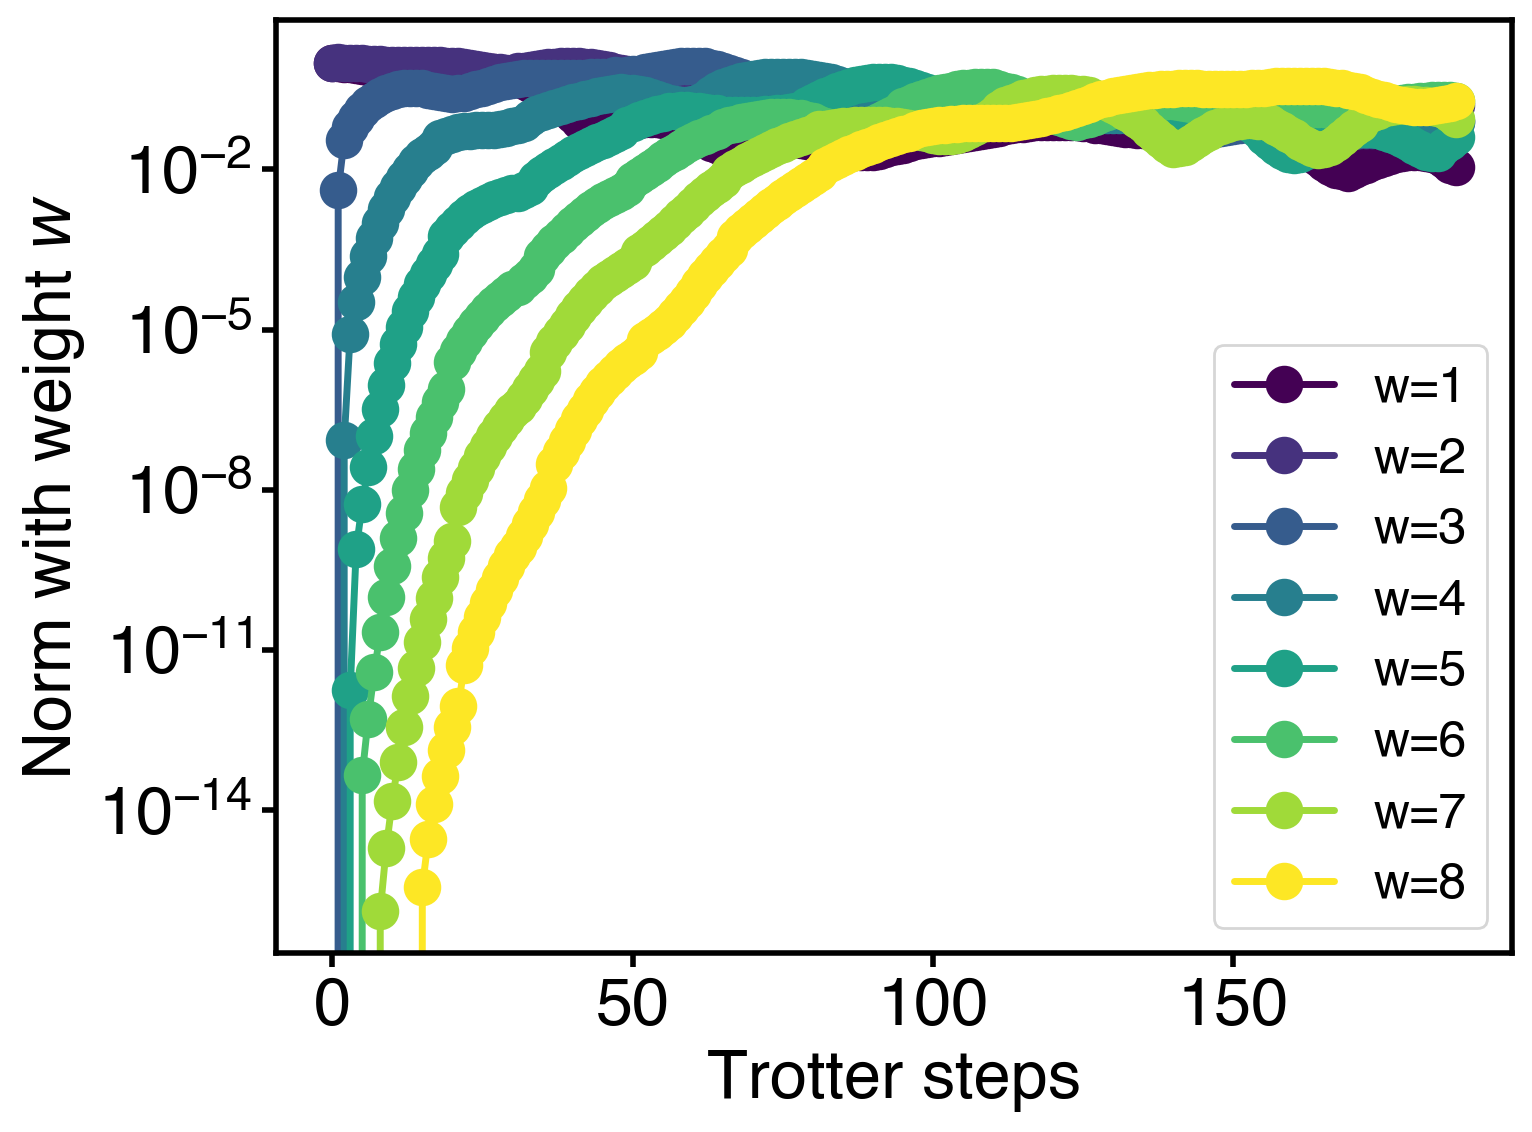

In [ ]:
norm_weight_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    for w in range(1, n+1):
        if w in item:
            temp_step.append(item[w])
        else:
            temp_step.append(0)
    norm_weight_steps.append(temp_step)
print('norm_weight_steps:', norm_weight_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(norm_weight_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(norm_weight_steps[0])):
    ax.plot(range(len(norm_weight_steps)), np.array(norm_weight_steps)[:, w], label=f'w={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'2-Norm with weight $w$')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/norm_weight_steps.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'Pauli weight distribution')

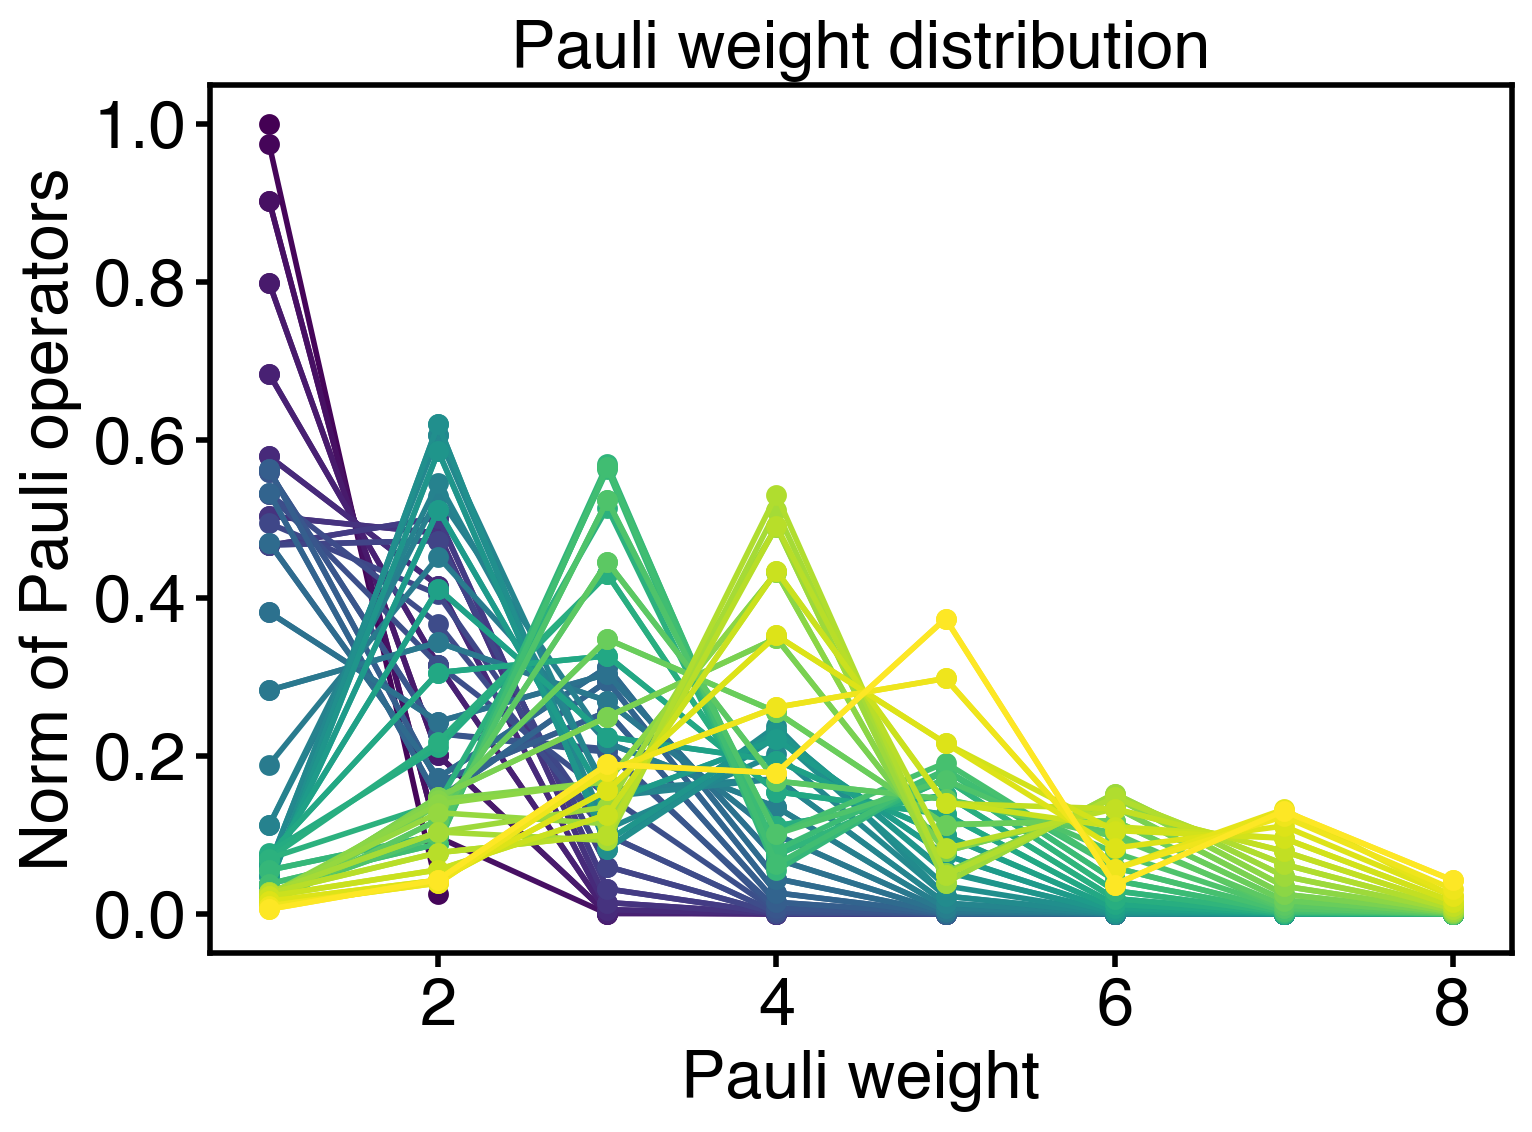

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
# use gradient color for each line
colors = plt.cm.viridis(np.linspace(0, 1, len(data_distribution)))
ax.set_prop_cycle(color=colors)
for i, item in enumerate(data_distribution):
    x = list(item.keys())
    y = [item[k] for k in x]
    ax.plot(x, y, label=f't={i*n}', marker='o', markersize=5, linewidth=2)
ax.set_xlabel('Pauli weight')
ax.set_ylabel('Norm of Pauli operators')
ax.set_title('Pauli weight distribution')